Matplotlib is building the font cache; this may take a moment.


--- FAKE DOOR TEST RESULTS ---
Data: 50 Visitors, 3 Conversions
Target Viability Line: 1.00%
------------------------------
Estimated Mean CVR:    7.69%
Lower Bound (95% safe):2.72%
------------------------------
✅ RESULT: PASS. Build the product.
We are 95% confident the true demand is above 1.00%.


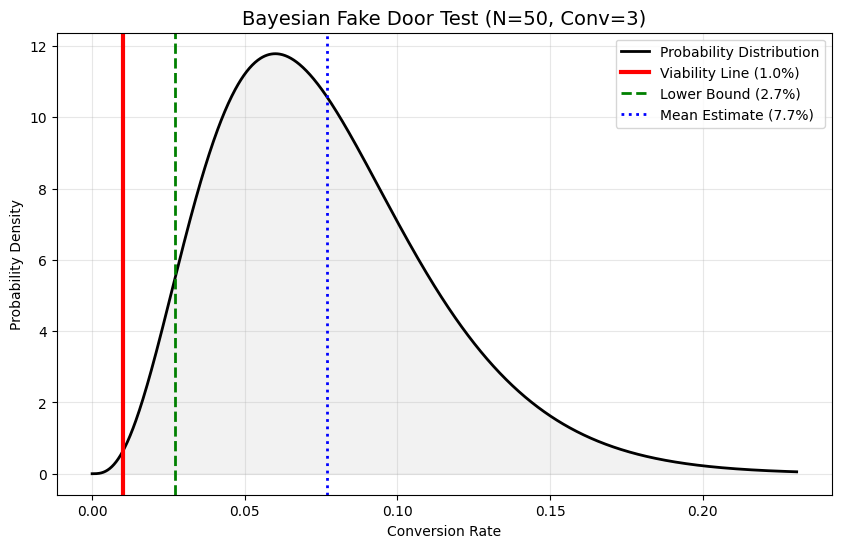

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def run_fake_door_test(visitors, conversions, target_cvr):
    """
    Calculates Bayesian probability and plots the result for a Fake Door Test.
    """
    
    # 1. Configuration & Priors (Weak Prior: Beta(1,1))
    prior_alpha = 1
    prior_beta = 1
    
    # 2. Update Posterior (The Learning)
    post_alpha = prior_alpha + conversions
    post_beta = prior_beta + (visitors - conversions)
    
    # 3. Calculate Key Stats
    # Mean (Expected Rate)
    mean_rate = post_alpha / (post_alpha + post_beta)
    
    # Lower Bound (95% Confidence / 5th Percentile)
    # This is the "Exact" computer version of the (Mean - 1.65*Std) rule.
    lower_bound = beta.ppf(0.05, post_alpha, post_beta)
    
    # 4. Print Results
    print(f"--- FAKE DOOR TEST RESULTS ---")
    print(f"Data: {visitors} Visitors, {conversions} Conversions")
    print(f"Target Viability Line: {target_cvr:.2%}")
    print(f"-" * 30)
    print(f"Estimated Mean CVR:    {mean_rate:.2%}")
    print(f"Lower Bound (95% safe):{lower_bound:.2%}")
    print(f"-" * 30)
    
    if lower_bound > target_cvr:
        print(f"✅ RESULT: PASS. Build the product.")
        print(f"We are 95% confident the true demand is above {target_cvr:.2%}.")
    else:
        print(f"❌ RESULT: FAIL (or need more data).")
        print(f"We cannot guarantee the demand is above {target_cvr:.2%}.")

    # 5. Plotting
    x = np.linspace(0, max(mean_rate * 3, target_cvr * 2), 1000)
    y = beta.pdf(x, post_alpha, post_beta)

    plt.figure(figsize=(10, 6))
    
    # Plot the curve
    plt.plot(x, y, label=f'Probability Distribution', color='black', lw=2)
    plt.fill_between(x, 0, y, alpha=0.1, color='gray')

    # Draw the vertical lines
    plt.axvline(target_cvr, color='red', linestyle='-', linewidth=3, label=f'Viability Line ({target_cvr:.1%})')
    plt.axvline(lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound ({lower_bound:.1%})')
    plt.axvline(mean_rate, color='blue', linestyle=':', linewidth=2, label=f'Mean Estimate ({mean_rate:.1%})')

    # Formatting
    plt.title(f'Bayesian Fake Door Test (N={visitors}, Conv={conversions})', fontsize=14)
    plt.xlabel('Conversion Rate')
    plt.ylabel('Probability Density')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    
    # Show plot
    plt.show()

# ==========================================
# ENTER YOUR DATA HERE & RUN
# ==========================================

# Example 1: The "Success" Case (50 visitors, 3 clicks)
run_fake_door_test(visitors=50, conversions=3, target_cvr=0.01)

# Example 2: The "Need More Data" Case (Your 200 visitors example)
# run_fake_door_test(visitors=200, conversions=18, target_cvr=0.05)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
print("Imports successful!")

Imports successful!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
print("All imports successful!")

All imports successful!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
print("All imports successful!")

All imports successful!
